<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/POWER_BI_DASHBOARD_SALES_SNAPSHOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DASHBOARD SALES SNAPSHOT**

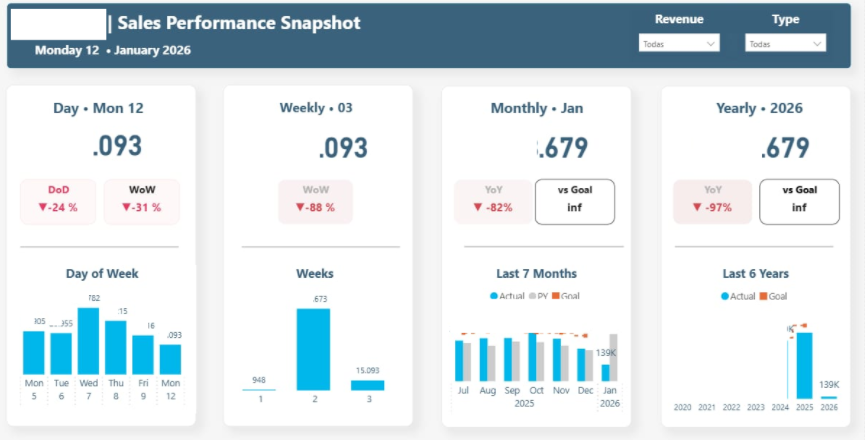

Fuente: Datos censurados de una  empresa b2b

El Query realizado fue inedito debido a la forma en la que se necesitaba contabilizar las renovaciones del servicio, existian algunos clientes

QUERY DEL REPORTE: --primero ventas

select  IdCliente,Cliente, CONVERT(date, FechaOrden) as FechaOP,Precio,IdAñoMesOrden as AñoMesOP,IdAñoMesRNV, OPnuerec,
region_clasif.idregion ,r.CodTipoEjecutivo, [Plan], '' as fechafin

from V_ReporteVentas_PBI r
left outer join
region_clasif  on r.codpais = region_clasif.codpais and region_clasif.codpais is not null  left outer join V_Ejecutivo E on r.Ejecutivo = E.Ejecutivo
where IdAñoMesOrden > 202400 and r.CodTipoEjecutivo not in ('RNV')  

union

-- RNV TOMANDO VENTA DE CARTERA + REPESCA

select O.idcliente,v.cliente,CONVERT(date, FechaOrden)   as FechaOP,o.Preciousd as Precio ,
CASE WHEN (YEAR(fechaorden)*100 + MONTH(fechaorden)) > O.IdAñoMesRNV  then (YEAR(fechaorden)*100 + MONTH(fechaorden)) else O.IdAñoMesRNV end as AñoMesOP,O.IdAñoMesRNV, O.NuevoRecurrente,
region_clasif.idregion,o.codtipoejecutivo,v.[Plan],o.FechaFinActual

from v_OrdenPedido O
inner join Ejecutivo E on O.IdEjecutivo = E.IdEjecutivo inner join V_CLIENTE V on O.idcliente = v.idcliente
left outer join region_clasif  on v.codpais = region_clasif.codpais and region_clasif.codpais is not null
where O.CodTipoEjecutivo='RNV' and O.IdAñomesRNV is not null and  O.codestado in ('ANP', 'FCT','TES')
and (CASE WHEN (YEAR(fechaorden)*100 + MONTH(fechaorden)) > O.IdAñoMesRNV  then (YEAR(fechaorden)*100 + MONTH(fechaorden)) else O.IdAñoMesRNV end) > 202400



El siguiente dashboard en power BI permite una visualización completa y de los ingresos diarios (hoy y dia anterior), mensual y acumualado anual ademas tiene filtros de REVENUE (para ventas o renovaciones) y type por tipo de venta puntual (ventas online por ejemplo)

El dashboard de POWER BI permite responder preguntas como:

Cual es el avance al cierre del dia? cuanto % por encima o debajo de ayer?

Cual es el acumulado contra la meta acumulada del mes?

Cual fue la mejor semana en el mes en curso?

Cuanto se vendio por REVENUE de renovaciones?

Ademas el reporte se actualiza 8 veces durante el dia y llega temprano por correo.